# Análisis de la matriz eléctrica europea mediante clustering

En este cuaderno exploramos los **perfiles de generación eléctrica de distintos países europeos**, 
poniendo el foco en las **similitudes y diferencias de sus mixes energéticos**.

### Metodología

Se trabajó con datasets de la **IEA** para los países de la **UE-27** (21 de los 27 con datos disponibles) correspondientes a las **matrices de generación eléctrica del año 2023**. En una primera instancia se aplicó **k-means**, con el objetivo de obtener **clusters compactos y fácilmente comunicables**, resumidos en centroides que permiten caracterizar rápidamente los perfiles promedio de cada grupo de países. Como complemento, se implementó también una **clusterización jerárquica**. Este método permitió **visualizar la estructura de proximidades paso a paso** y, sobre todo, **resaltar los casos más aislados** que en k-means quedaban forzados dentro de algún cluster aunque sus perfiles fueran atípicos.


### Objetivos
- Analizar la composición de las matrices eléctricas nacionales a partir de distintas fuentes de energía (carbón, gas, nuclear, hidro, renovables variables, etc.).
- Identificar patrones comunes mediante **clustering jerárquico y k-means**.
- Visualizar los resultados con herramientas como **heatmaps, PCA y dendrogramas**.
- Interpretar los clusters en términos de **estrategias de transición energética**: países muy nucleares, sistemas hidro-dependientes, pioneros en eólica/solar, etc.

### Estructura del notebook
1. **Carga y preprocesamiento de datos**  
   Limpieza, normalización y armado de la matriz de features.
2. **Exploración inicial**  
   Heatmaps de correlaciones y distancias entre países.
3. **Clustering jerárquico y k-means**  
   Construcción de dendrogramas y asignación de clusters.
4. **Visualización con PCA**  
   Reducción de dimensionalidad para ver la estructura en 2D.
5. **Interpretación de resultados**  
   Discusión de cada cluster y sus implicancias energéticas.

---

📌 *Este análisis permite entender qué países siguen perfiles energéticos similares, 
cómo se agrupan en función de su dependencia fósil, nuclear o renovable, 
y qué rol ocupan en la transición energética europea.*


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns
from adjustText import adjust_text
from IPython.display import display
import geopandas as gpd
import fiona

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"  
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1"
from threadpoolctl import threadpool_limits
threadpool_limits(1)

In [3]:
#Se importaron todos los csvs y se unieron en un único dataframe.
import glob
files = glob.glob("data/*.csv") 
df_list = []

for file in files:
    country = file.split("\\")[-1].replace(".csv", "")
    temp = pd.read_csv(file)
    col_energy = [c for c in temp.columns if "electricity generation" in c.lower()][0]
    temp = temp.rename(columns={col_energy: "Energy_source"})
    temp["Country"] = country
    df_list.append(temp)

df_all = pd.concat(df_list, ignore_index=True)

In [4]:
df_all= df_all[df_all['Year']==2023]
df_all

,Energy_source,Value,Year,Units,Country
23,Coal,1928.0,2023,GWh,Austria
47,Oil,781.0,2023,GWh,Austria
71,Natural gas,7495.0,2023,GWh,Austria
95,Hydro,44523.0,2023,GWh,Austria
119,Biofuels,4188.0,2023,GWh,Austria
...,...,...,...,...,...
4799,Biofuels,5625.0,2023,GWh,The Netherlands
4823,Waste,3787.0,2023,GWh,The Netherlands
4847,Wind,29525.0,2023,GWh,The Netherlands
4871,Solar PV,19578.0,2023,GWh,The Netherlands


In [5]:
df_all = df_all.pivot(index="Country", columns="Energy_source", values="Value").fillna(0)

In [6]:
#Se normalizó el DF para volver comparables las matrices
df_all = df_all.div(df_all.sum(axis=1), axis=0) * 100
df_all

Energy_source,Biofuels,Coal,Geothermal,Hydro,Natural gas,Nuclear,Oil,Other sources,Solar PV,Solar thermal,Tide,Waste,Wind
Country,,,,,,,,,,,,,
Austria,5.624874,2.589484,0.000000,59.798536,10.066483,0.000000,1.048956,0.016117,8.587738,0.000000,0.000000,1.474716,10.793097
Belgium,3.389749,2.189711,0.000000,1.978151,21.860059,39.356234,0.235466,0.494836,9.346911,0.000000,0.000000,2.690524,18.458357
Czechia,6.545540,39.470642,0.000000,4.450707,4.758503,39.494019,0.115586,0.148054,3.755893,0.000000,0.000000,0.350654,0.910401
Denmark,16.344016,7.485696,0.000000,0.056328,2.964632,0.000000,0.708547,0.000000,9.970057,0.000000,0.000000,4.977617,57.493107
Estonia,23.054153,48.929131,0.000000,0.417900,0.365663,0.000000,0.313425,0.000000,12.554414,0.000000,0.000000,2.472575,11.892739
Finland,13.368899,4.142752,0.000000,18.641158,0.809419,42.075055,0.277165,0.295560,0.878097,0.000000,0.000000,1.063282,18.448614
France,1.486146,0.584223,0.024351,11.576034,5.676537,64.339158,1.176437,0.280983,4.151582,0.000000,0.085417,0.824115,9.795018
Germany,7.853989,26.352270,0.038095,4.949793,15.799601,1.409705,1.049465,0.302415,12.420098,0.000000,0.000000,2.369305,27.455263
Greece,1.310306,9.196185,0.000000,8.102260,32.014345,0.000000,9.394534,0.000000,17.817359,0.000000,0.000000,0.084148,22.080862


In [7]:
df_all_grouped = pd.DataFrame()

# Mantenemos carbón separado
df_all_grouped["Coal"] = df_all["Coal"]

# Agrupamos petróleo y gas en "Oil & Gas"
df_all_grouped["Oil & Gas"] = df_all["Oil"] + df_all["Natural gas"]

df_all_grouped["Nuclear"] = df_all["Nuclear"]

# Renovables tradicionales: hidro, biomasa, residuos, geotermia y marea
df_all_grouped["Renewables_trad"] = (
    df_all["Hydro"] + df_all["Biofuels"] + 
    df_all["Waste"] + df_all.get("Geothermal", 0) + df_all.get("Tide", 0)
)

# Renovables variables: viento + solar
df_all_grouped["Renewables_var"] = (
    df_all["Wind"] + df_all["Solar PV"] + df_all.get("Solar thermal", 0)
)

# Otros (incluye mareas y "Other sources" si existen)
df_all_grouped["Other"] = (
    df_all.get("Other sources", 0) 
)

# Conservamos el índice (clusters o países, según lo que tengas)
df_all_grouped.index = df_all.index
df_all=df_all_grouped
df_all

,Coal,Oil & Gas,Nuclear,Renewables_trad,Renewables_var,Other
Country,,,,,,
Austria,2.589484,11.115439,0.000000,66.898126,19.380834,0.016117
Belgium,2.189711,22.095525,39.356234,8.058424,27.805269,0.494836
Czechia,39.470642,4.874089,39.494019,11.346901,4.666294,0.148054
Denmark,7.485696,3.673179,0.000000,21.377961,67.463164,0.000000
Estonia,48.929131,0.679088,0.000000,25.944628,24.447153,0.000000
Finland,4.142752,1.086583,42.075055,33.073338,19.326711,0.295560
France,0.584223,6.852974,64.339158,13.996062,13.946600,0.280983
Germany,26.352270,16.849066,1.409705,15.211182,39.875361,0.302415
Greece,9.196185,41.408880,0.000000,9.496714,39.898221,0.000000


In [8]:
#Se excluyó Other, dado que su carácter marginal en la mayoría de los países no justificaba su inclusión y sólo introducía ruido en el proceso de clusterización.
feature_cols = ["Coal", "Oil & Gas", "Nuclear", "Renewables_trad", "Renewables_var"]
df_all= df_all[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_all)

## Selección del número de clusters (k)

Para determinar k en k-means usamos dos criterios estándar:

- **Elbow (inercia):** mide la suma de distancias cuadráticas de los puntos a su centroide.
  La inercia siempre disminuye al aumentar k; se elige el punto donde la mejora
  adicional se “estanca” (el “codo”).

- **Silhouette:** evalúa qué tan bien quedan separados los clusters (rango -1 a 1).
  Valores más altos indican asignaciones más coherentes y mayor separación entre grupos.

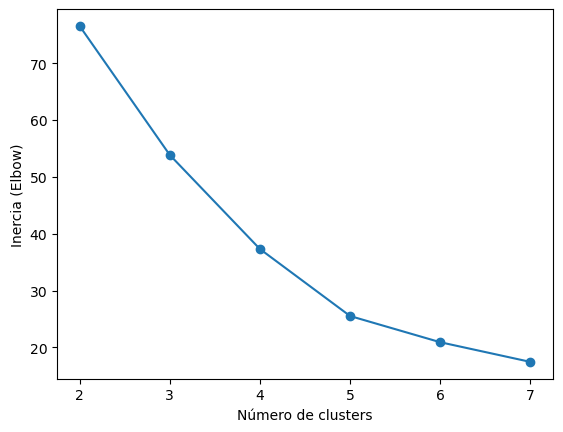

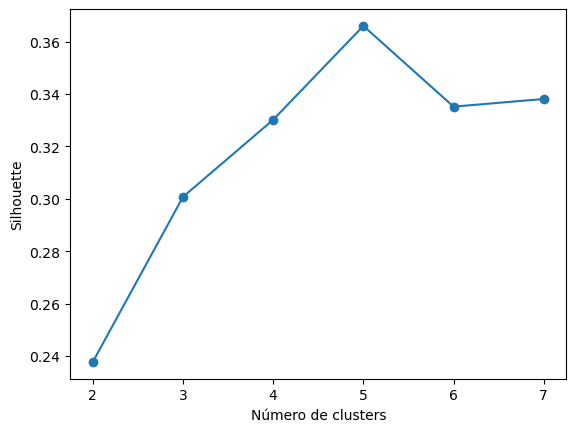

In [9]:
# Criterios de selección de k: Elbow y Silhouette.

inertia = []
silhouette = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto',random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia (Elbow)")
plt.show()

plt.plot(K_range, silhouette, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

**Resultado:** en nuestros datos, el codo se observa alrededor de *k = 4–5* y el promedio de
silhouette es máximo en *k = 5*. Por lo tanto, **adoptamos k = 5** para el modelo principal. También se probaron clusterizaciones con 4 y 6 clusters pero *el mejor resultado fue con k=5*.  


## Metodología de clustering

Se aplicaron dos métodos de agrupamiento con enfoques complementarios:
- **K-means:** asigna cada país a un cluster según la cercanía a un centroide y busca minimizar la varianza interna.
  - *Fortalezas:* rápido, resultados compactos y fáciles de interpretar mediante centroides promedio.
  - *Limitaciones:* requiere definir k a priori y asume clusters aproximadamente esféricos. Esto hace que los **casos atípicos** se integren forzadamente dentro de algún cluster, aunque su perfil energético sea claramente distinto.
  - En este análisis se aplicó k-means sobre el espacio completo de **5 dimensiones** (todas las fuentes energéticas consideradas), ya que ofreció agrupamientos más coherentes en términos de perfiles que al reducir previamente la dimensionalidad. La **reducción a 2 dimensiones mediante PCA** se utilizó únicamente con fines de **visualización** de los clusters y sus centroides.
- **Clustering jerárquico:** construye una jerarquía de similitudes y permite visualizarla mediante un dendrograma.
  - *Fortalezas:* no exige fijar k de entrada, muestra relaciones de proximidad paso a paso, resalta países con perfiles atípicos.
  - *Limitaciones:* Tiene una comunicación más compleja que K-means.
**Estrategia adoptada:**  
K-means se utilizó como método principal por su claridad y comunicación directa, mientras que el jerárquico sirvió de complemento para detectar casos atípicos y validar la robustez de los agrupamientos.

In [10]:
#Clusterización en 5d
pca = PCA(n_components=2, random_state=42)
#Z = pca.fit_transform(X_scaled) #comentado por si se prefiere clusterizar en 2d
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df_all["Cluster"] = labels
print(df_all[["Cluster"]])


                 Cluster
Country                 
Austria                1
Belgium                2
Czechia                2
Denmark                3
Estonia                0
Finland                2
France                 2
Germany                0
Greece                 4
Hungary                2
Ireland                4
Italy                  4
Latvia                 1
Lithuania              3
Luxembourg             1
Poland                 0
Portugal               3
Slovak Republic        2
Spain                  4
Sweden                 1
The Netherlands        4


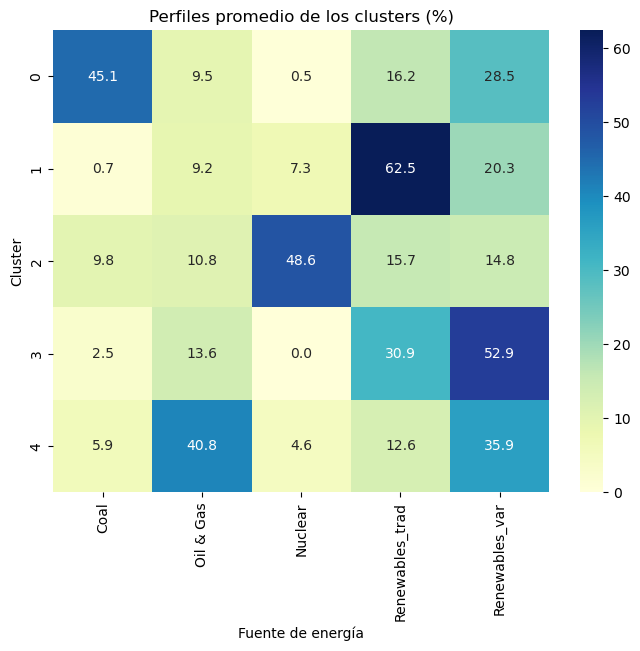

In [11]:
Z = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    "PC1": Z[:,0],
    "PC2": Z[:,1],
    "Cluster": df_all["Cluster"].values,
    "Country": df_all.index
})

profiles = (
    df_all.drop(columns=["Cluster", "Cluster_hier"], errors="ignore")
          .assign(Cluster=df_all["Cluster"])
          .groupby("Cluster").mean()
          .sort_index()
)

# Heatmap de perfiles promedio por cluster
plt.figure(figsize=(8,6))
sns.heatmap(profiles, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfiles promedio de los clusters (%)")
plt.ylabel("Cluster")
plt.xlabel("Fuente de energía")
plt.show()

C:\Users\Santiago\AppData\Local\Temp\ipykernel_27388\2341893555.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10")


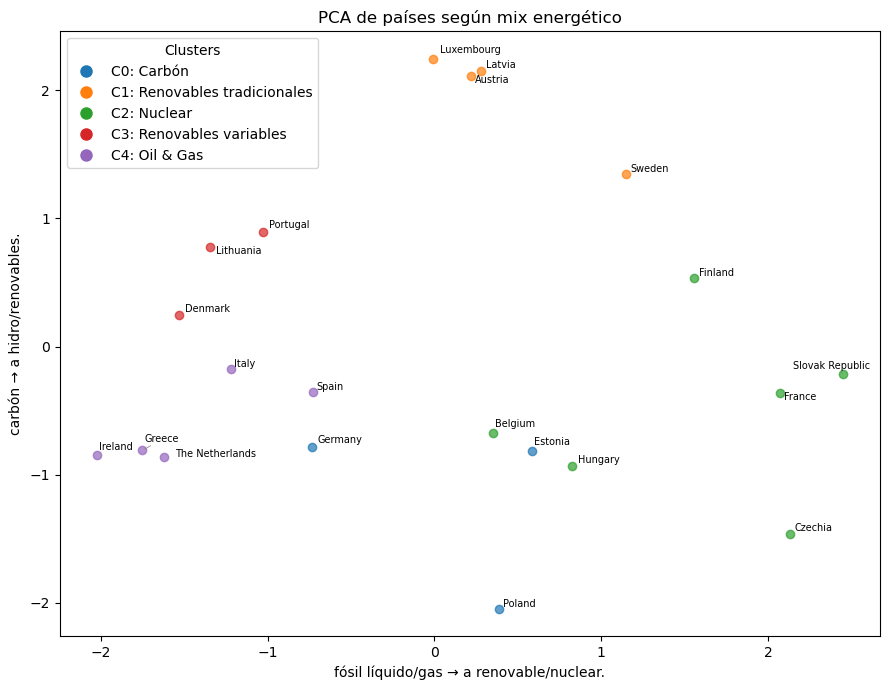

In [12]:
from matplotlib.lines import Line2D
clusters_sorted = np.sort(np.unique(labels))

cluster_labels = {
    0: "C0: Carbón",
    1: "C1: Renovables tradicionales",
    2: "C2: Nuclear",
    3: "C3: Renovables variables",
    4: "C4: Oil & Gas",
}
cmap = plt.cm.get_cmap("tab10")
palette = {c: cmap(i % 10) for i, c in enumerate(sorted(clusters_sorted))}

plt.figure(figsize=(9,7))
# scatter de países
for c in clusters_sorted:
    mask = (labels == c)
    plt.scatter(Z[mask,0], Z[mask,1], alpha=0.7)

# etiquetas de países sin superposición
texts = []
for (x, y), name in zip(Z, df_all.index):
    texts.append(plt.text(x, y, name, fontsize=7))

# autoajuste
adjust_text(texts,
            only_move={'points':'y', 'texts':'y'},  # mueve en vertical para ordenarlos
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

legend_elements = []

# proxy por cada cluster
for c in clusters_sorted:
    legend_elements.append(
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=palette[c], markeredgecolor=palette[c],
               markersize=8, label=cluster_labels.get(c, f"C{c}"))
    )

plt.xlabel("fósil líquido/gas → a renovable/nuclear.")
plt.ylabel("carbón → a hidro/renovables.")
plt.title("PCA de países según mix energético")
plt.legend(handles=legend_elements,title="Clusters",loc="upper left")
plt.tight_layout()
plt.show()

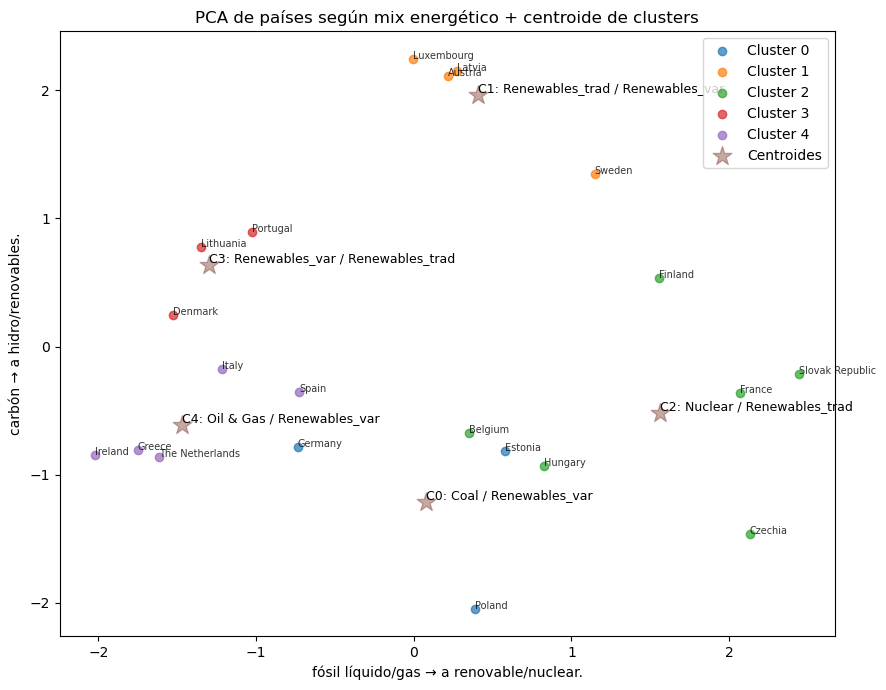

In [13]:
# 1) Matriz de features (sin la col Cluster)
features_df = df_all.drop(columns=["Cluster"], errors="ignore").copy()
feature_names = features_df.columns.tolist()

# 3) PCA 2D
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

# 4) Centroides en espacio original-escalado y su proyección al PCA     
labels = df_all["Cluster"].values

centroids = []
for c in clusters_sorted:
    mask = (labels == c)
    centroids.append(X_scaled[mask].mean(axis=0))
centroids = np.vstack(centroids)
centroids_pca = pca.transform(centroids)

# 5) Perfiles promedio por cluster (en % para nombrar centroides)
profiles = (df_all.drop(columns="Cluster")
                  .assign(Cluster=labels)
                  .groupby("Cluster").mean()
                  .sort_index())

# Nombres humanos por top-2 fuentes
topk = 2
centroid_names = []
for c in profiles.index:
    tops = profiles.loc[c].sort_values(ascending=False).head(topk).index.tolist()
    centroid_names.append(" / ".join(tops))

# 6) Scatter: países por cluster + centroides
plt.figure(figsize=(9,7))
for c in clusters_sorted:
    mask = (labels == c)
    plt.scatter(Z[mask,0], Z[mask,1], label=f"Cluster {c}", alpha=0.7)

# centroides (marcador grande tipo X)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker="*", s=200, label="Centroides", alpha=0.5)

# Etiquetas de centroides con top-2 fuentes
for i, c in enumerate(clusters_sorted):
    plt.text(centroids_pca[i,0], centroids_pca[i,1],
             f"C{c}: {centroid_names[i]}",
             fontsize=9, ha="left", va="bottom")

# (Opcional) anotar países — activá si querés ver nombres
annotate_countries = True
if annotate_countries:
    for (x, y), name in zip(Z, df_all.index):
        plt.text(x, y, name, fontsize=7, alpha=0.8)

plt.xlabel("fósil líquido/gas → a renovable/nuclear.")
plt.ylabel("carbón → a hidro/renovables.")
plt.title("PCA de países según mix energético + centroide de clusters")
plt.legend()
plt.tight_layout()
plt.show()


## Caracterización de los clusters

A partir de los perfiles promedio de cada grupo, se pueden resumir las principales características energéticas de los clusters identificados:

- **Cluster 0 → Carbón**  
  Sistemas eléctricos con fuerte dependencia del **carbón** (≈45%), acompañado por una participación secundaria de renovables variables.  
- **Cluster 1 → Renovables tradicionales**  
  Predominio de **hidroeléctrica y biomasa** (≈62%), complementadas con renovables variables. Representa países con matrices muy basadas en fuentes gestionables.  
- **Cluster 2 → Nuclear**  
  Perfil dominado por la **energía nuclear** (≈49%), con presencia secundaria de carbón y otras fuentes. Agrupa a países con una base eléctrica nuclear sólida.  
- **Cluster 3 → Renovables variables**  
  Matrices con peso muy alto de **eólica y solar** (≈53%), acompañadas por renovables tradicionales. Refleja sistemas en transición acelerada hacia renovables intermitentes.  
- **Cluster 4 → Oil & Gas**  
  Predominio de **gas y petróleo** (≈41%), con un aporte importante de renovables variables (≈36%). Muestra una combinación fósil–renovable, dependiente de combustibles fósiles pero con integración creciente de eólica/solar.  
- **Algunos casos atípicos:** Son casos que por la limitación del metódo quedan en un cluster que oculta ciertas caracteristicas particulares del país. 
  *Alemania:* Forma parte del cluster 0 por su alto uso de carbón aunque tenga un alto perfil renovable variable.
  *Suecia:* Integra el cluster 1 por su alto contenido de renovables tradicionales, aunque tenga una matriz muy similar a Finlandia. Sin embargo, esto oculta el perfil núclear del país, lo cual lo acercaría a un cluster con Francia, Chequia o Bélgica. 
---

### Limitaciones de K-means y motivación del análisis jerárquico

El método **K-means** permitió identificar agrupamientos claros y fácilmente comunicables. Sin embargo, presenta limitaciones: al forzar a todos los países a integrarse en algún cluster, termina **ocultando ciertos casos atípicos** o híbridos (por ejemplo, Alemania junto a Polonia y Estonia, o Suecia dentro del bloque de renovables tradicionales).

Para complementar el análisis, se aplicará ahora una **clusterización jerárquica**. Este enfoque no requiere fijar *k* de antemano y permite visualizar la estructura de similitudes de manera progresiva, lo que ayuda a **resaltar mejor los países con perfiles energéticos distintivos** y a validar la robustez de los agrupamientos encontrados.


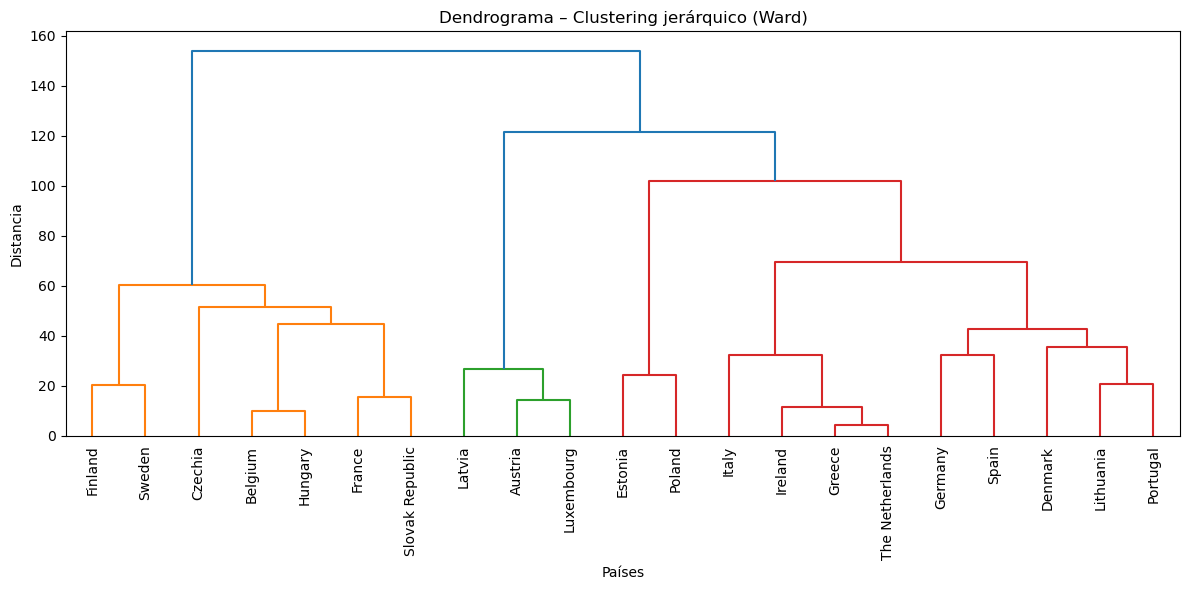

                 Cluster_hier
Country                      
Austria                     2
Belgium                     1
Czechia                     1
Denmark                     5
Estonia                     3
Finland                     1
France                      1
Germany                     5
Greece                      4
Hungary                     1
Ireland                     4
Italy                       4
Latvia                      2
Lithuania                   5
Luxembourg                  2
Poland                      3
Portugal                    5
Slovak Republic             1
Spain                       5
Sweden                      1
The Netherlands             4


In [14]:
X = df_all.drop(columns=["Cluster"], errors="ignore").values

# --- 2. Clustering jerárquico (Ward) ---
Z_link = linkage(X, method='ward')

# --- 3. Graficar dendrograma ---
plt.figure(figsize=(12, 6))
dendrogram(
    Z_link,
    labels=df_all.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None # o un valor para colorear cortes
)
plt.title("Dendrograma – Clustering jerárquico (Ward)")
plt.xlabel("Países")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

# --- 4. Si querés extraer clusters (ej: 6) ---
clusters_hier = fcluster(Z_link, 5,  criterion='maxclust')
df_all["Cluster_hier"] = clusters_hier

print(df_all[["Cluster_hier"]])


In [15]:
comparativa = df_all[["Cluster", "Cluster_hier"]].copy()
comparativa.head()

comparativa["Comentario"] = ""
comparativa.loc["Germany", "Comentario"] = "De fósil a renovables variables"
comparativa.loc["Sweden", "Comentario"] = "Pasó de cluster renovable a cluster nuclear"
comparativa.loc["Poland", "Comentario"] = "Formó un cluster particular junto a Estonia"
comparativa.loc["Estonia", "Comentario"] = "Formó un cluster particular junto a Polonia"

display(comparativa)

,Cluster,Cluster_hier,Comentario
Country,,,
Austria,1,2,
Belgium,2,1,
Czechia,2,1,
Denmark,3,5,
Estonia,0,3,Formó un cluster particular junto a Polonia
Finland,2,1,
France,2,1,
Germany,0,5,De fósil a renovables variables
Greece,4,4,


## Comparación entre K-means y Clustering jerárquico (5 clusters)

Ambos métodos permiten identificar 5 agrupamientos, pero difieren en algunos países clave:

- **Coincidencias generales**  
  - Los bloques principales (Carbón, Nuclear, Renovables tradicionales, Renovables variables, Oil & Gas) aparecen en ambos métodos.  
  - La mayoría de los países mantiene su asignación en el mismo perfil energético.  
- **Diferencias destacadas**  
  - **Alemania:**  
    - *K-means:* cercana a Polonia y Estonia (arrastrada por fósiles).  
    - *Jerárquico:* queda en el mismo cluster que España, Dinamarca y Portugal (más asociado a renovables variables).  
  -  **Polonia y Estonia:**  
    - *K-means:* cercanos a Alemania.  
    - *Jerárquico:* rapidamente forman un cluster separado, mostrando su perfil particular en terminos de matriz energética.  
  - **Suecia y Finlandia:**  
    - *K-means:* Suecia agrupada con renovables tradicionales, Finlandia con nucleares/renovables.  
    - *Jerárquico:* ambos se ubican juntos en el mismo cluster, resaltando su perfil mixto (nuclear + hidro).
  - **Portugal, Lituania y Dinamarca:**
    - *K-means:* aparecían como un cluster propio por su alto perfil renovable variable.
    - *Jerárquico:* se integran a España y Alemania, creando un cluster alto renovable pero sin alta presencia de gas y petróleo (como el cluster 4)
- **Interpretación**  
  - **K-means**: genera clusters más compactos y “promedio”, pero oculta casos híbridos o atípicos.  
  - **Jerárquico**: permite visualizar similitudes más finas y agrupa mejor a los países con perfiles transicionales (ej. Alemania, Lituania).  
**Conclusión:**  
El uso combinado de ambos métodos aporta valor. K-means facilita la comunicación de perfiles promedios, mientras que el análisis jerárquico complementa la lectura al resaltar afinidades específicas y casos atípicos que no se captan en el primer método.


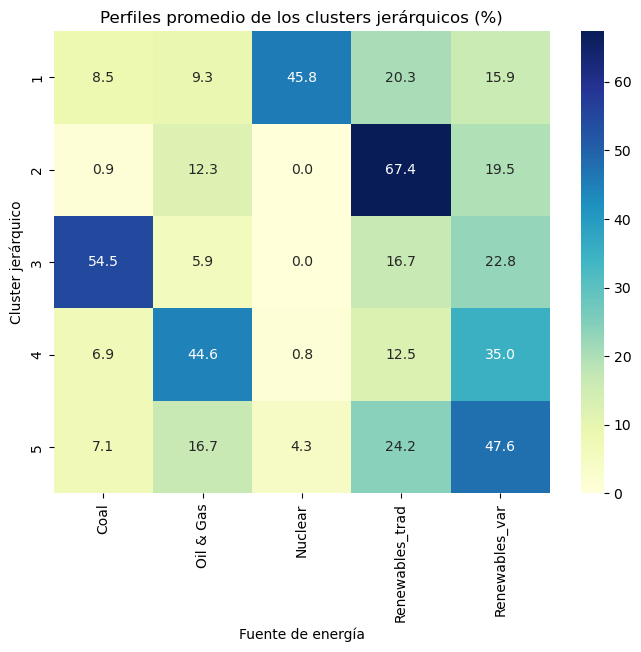

In [16]:
profiles_hier = (
    df_all.drop(columns=["Cluster"], errors="ignore") 
          .assign(Cluster_hier=df_all["Cluster_hier"])
          .groupby("Cluster_hier").mean()
          .sort_index()
)
plt.figure(figsize=(8,6))
sns.heatmap(profiles_hier, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfiles promedio de los clusters jerárquicos (%)")
plt.ylabel("Cluster jerárquico")
plt.xlabel("Fuente de energía")
plt.show()

## Comparación de perfiles promedio: K-means vs. Clustering jerárquico

- **Clusters de Carbón**  
  - *K-means (C0):* 45% carbón.  
  - *Jerárquico (C3):* 55% carbón.  
  → Ambos métodos detectan un bloque muy marcado por carbón, aunque el jerárquico lo concentra aún más.
- **Clusters de Renovables tradicionales (hidro/biomasa)**  
  - *K-means (C1):* 62% renovables tradicionales.  
  - *Jerárquico (C2):* 67% renovables tradicionales.  
  → Muy consistentes: se confirma un grupo hidro-dependiente.
- **Clusters nucleares**  
  - *K-means (C2):* 49% nuclear.  
  - *Jerárquico (C1):* 46% nuclear.  
  → Ambos capturan claramente el bloque nuclear.
- **Clusters de Renovables variables (eólica/solar)**  
  - *K-means (C3):* 53% renovables variables.  
  - *Jerárquico (C5):* 48% renovables variables.  
  → Coherentes: destacan un grupo con fuerte penetración de variables.
- **Clusters Oil & Gas**  
  - *K-means (C4):* 41% gas/petróleo + 36% renovables variables.  
  - *Jerárquico (C4):* 45% gas/petróleo + 35% renovables variables.  
  → Ambos coinciden en identificar un cluster fósil–renovable.

**Conclusión:**  
Los dos métodos convergen en la caracterización de los grandes bloques (Carbón, Nuclear, Renovables tradicionales, Renovables variables, Oil & Gas). Las diferencias aparecen en países híbridos o atípicos, pero a nivel de perfiles promedio, la consistencia es muy alta, lo que valida la robustez del análisis.

In [17]:
fiona.listlayers("data/CNTR_RG_20M_2024_3035.gpkg")

['CNTR_RG_20M_2024_3035.gpkg']

In [18]:
eu = gpd.read_file("data/CNTR_RG_20M_2024_3035.gpkg", layer="CNTR_RG_20M_2024_3035.gpkg")
eu.head()
eu.columns
eu.crs
europe_iso2 = [
    "AL","AD","AT","BY","BE","BA","BG","HR","CY","CZ","DK","EE","FI","FR","DE","GR",
    "HU","IS","IE","IT","XK","LV","LI","LT","LU","MT","MD","MC","ME","NL","MK","NO",
    "PL","PT","RO","RU","SM","RS","SK","SI","ES","SE","CH","TR","UA","GB","VA"
]
eu = eu[eu["CNTR_ID"].isin(europe_iso2)].copy()

In [19]:
df_all = eu.merge(
    df_all,
    left_on="NAME_ENGL",
    right_on="Country",
    how="left"
)

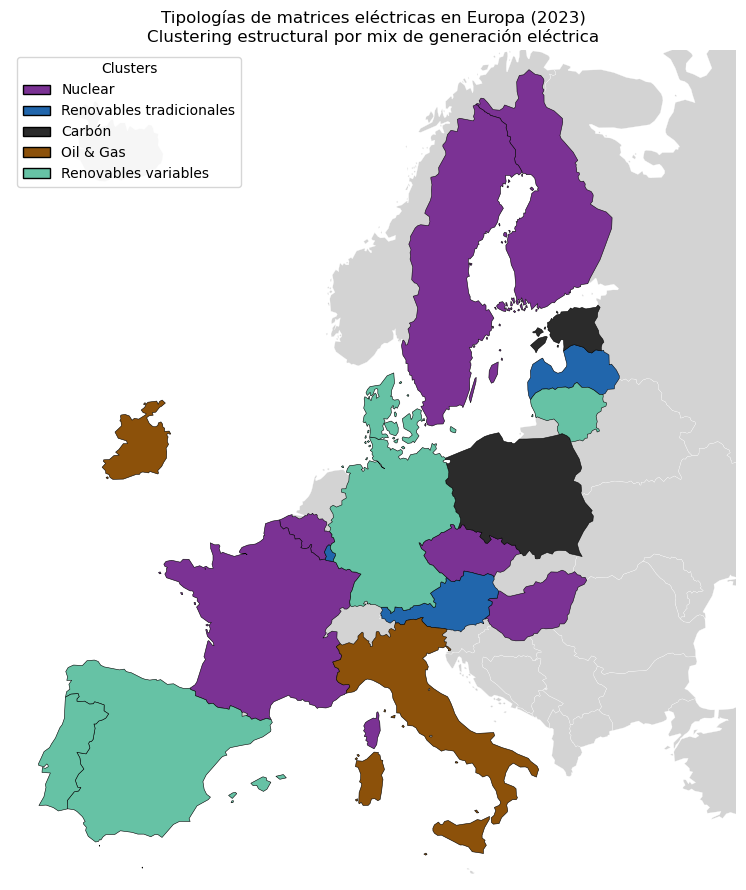

In [20]:
from matplotlib.patches import Patch

# Paleta semántica
cluster_colors = {
    1: "#7b3294",  # Nuclear → violeta
    2: "#2166ac",  # Renovables tradicionales → azul
    3: "#2b2b2b",  # Carbón → negro
    4: "#8c510a",  # Oil & Gas → marrón
    5: "#66c2a5",  # Renovables variables → verde claro
}

cluster_labels = {
    1: "Nuclear",
    2: "Renovables tradicionales",
    3: "Carbón",
    4: "Oil & Gas",
    5: "Renovables variables",
}


fig, ax = plt.subplots(figsize=(9, 9))

# 1) Fondo: países sin cluster (gris)
df_all[df_all["Cluster_hier"].isna()].plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.2
)

# Máscara por zona (Europa)
xmin, xmax = 2500000, 6000000
ymin, ymax = 1400000, 5400000

# 2) Países con cluster: plot uno por uno para controlar color
for c, color in cluster_colors.items():
    df_all[df_all["Cluster_hier"] == c].plot(
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.4
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Leyenda manual
legend_elements = [
    Patch(facecolor=cluster_colors[c], edgecolor="black", label=cluster_labels[c])
    for c in cluster_colors
]

ax.legend(
    handles=legend_elements,
    title="Clusters",
    loc="upper left",
    frameon=True
)

ax.set_title(
    "Tipologías de matrices eléctricas en Europa (2023)\n"
    "Clustering estructural por mix de generación eléctrica",
    fontsize=12
)

ax.axis("off")
plt.tight_layout()
plt.show()





### Conclusión
El uso combinado de ambos métodos permite una visión equilibrada:  
- **K-means** para comunicar perfiles promedio de forma clara.  
- **Jerárquico** para profundizar en la estructura interna y resaltar particularidades.  

En conjunto, el análisis muestra que los sistemas eléctricos europeos se agrupan en bloques energéticos coherentes y diferenciados, con algunos países clave (Alemania o Suecia) que presentan **perfiles híbridos** y requieren un análisis más detallado para comprender su rol en la transición energética.

## Replicación del análisis para 2010

Con el objetivo de evaluar la evolución de las tipologías de matrices eléctricas europeas, se replica exactamente la metodología aplicada para 2023 sobre los datos correspondientes a 2010.

La utilización del mismo procedimiento —preparación de datos, estandarización de variables, selección del número de clusters, K-Means, análisis mediante PCA y clustering jerárquico— garantiza que las diferencias observadas entre ambos años respondan a cambios en la estructura de las matrices eléctricas y no a modificaciones en la metodología de análisis.

Esta comparación permitirá identificar la persistencia, transformación o aparición de nuevas tipologías de generación eléctrica en Europa entre 2010 y 2023, proporcionando una perspectiva de largo plazo sobre la transición energética del continente.

In [21]:
#Se importaron todos los csvs y se unieron en un único dataframe.
import glob
files = glob.glob("data/*.csv") 
df_list = []

for file in files:
    country = file.split("\\")[-1].replace(".csv", "")
    temp = pd.read_csv(file)
    col_energy = [c for c in temp.columns if "electricity generation" in c.lower()][0]
    temp = temp.rename(columns={col_energy: "Energy_source"})
    temp["Country"] = country
    df_list.append(temp)

df_2010 = pd.concat(df_list, ignore_index=True)

In [22]:
df_2010= df_2010[df_2010['Year']==2010]
df_2010 = df_2010.pivot(index="Country", columns="Energy_source", values="Value").fillna(0)

In [23]:
df_2010_grouped = pd.DataFrame()

# Mantenemos carbón separado
df_2010_grouped["Coal"] = df_2010["Coal"]

# Agrupamos petróleo y gas en "Oil & Gas"
df_2010_grouped["Oil & Gas"] = df_2010["Oil"] + df_2010["Natural gas"]

df_2010_grouped["Nuclear"] = df_2010["Nuclear"]

# Renovables tradicionales: hidro, biomasa, residuos, geotermia y marea
df_2010_grouped["Renewables_trad"] = (
    df_2010["Hydro"] + df_2010["Biofuels"] + 
    df_2010["Waste"] + df_2010.get("Geothermal", 0) + df_2010.get("Tide", 0)
)

# Renovables variables: viento + solar
df_2010_grouped["Renewables_var"] = (
    df_2010["Wind"] + df_2010["Solar PV"] + df_2010.get("Solar thermal", 0)
)

# Otros (incluye mareas y "Other sources" si existen)
df_2010_grouped["Other"] = (
    df_2010.get("Other sources", 0) 
)

# Conservamos el índice (clusters o países, según lo que tengas)
df_2010_grouped.index = df_2010.index
df_2010=df_2010_grouped

#Se normalizó el DF para volver comparables las matrices
df_2010 = df_2010.div(df_2010.sum(axis=1), axis=0) * 100
df_2010

,Coal,Oil & Gas,Nuclear,Renewables_trad,Renewables_var,Other
Country,,,,,,
Austria,9.424651,21.967886,0.000000,65.559180,3.024381,0.023903
Belgium,6.294593,33.028910,50.678083,7.733206,1.985096,0.280112
Czechia,57.901354,1.817166,32.592575,6.482893,1.107063,0.098949
Denmark,43.761097,22.336018,0.000000,13.792749,20.110136,0.000000
Estonia,89.293428,2.653502,0.000000,5.916384,2.136686,0.000000
Finland,26.543868,14.556115,28.261894,29.885713,0.370627,0.381783
France,4.622449,5.143100,75.273280,13.081627,1.855830,0.023714
Germany,43.191970,15.651535,22.200531,10.686126,7.940991,0.328848
Greece,53.648637,27.731034,0.000000,13.617281,5.003049,0.000000


In [24]:
#Se excluyó Other, dado que su carácter marginal en la mayoría de los países no justificaba su inclusión y sólo introducía ruido en el proceso de clusterización.
feature_cols = ["Coal", "Oil & Gas", "Nuclear", "Renewables_trad", "Renewables_var"]
df_2010= df_2010[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_2010)

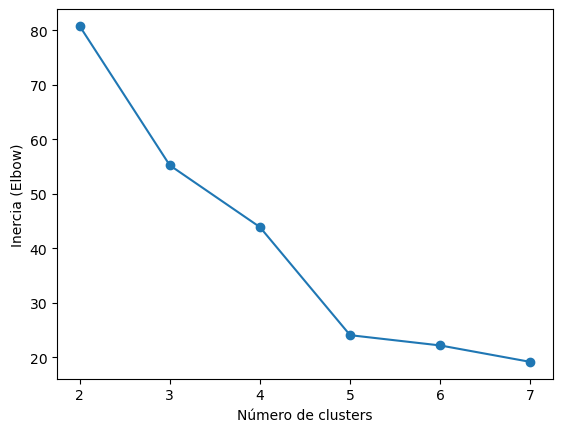

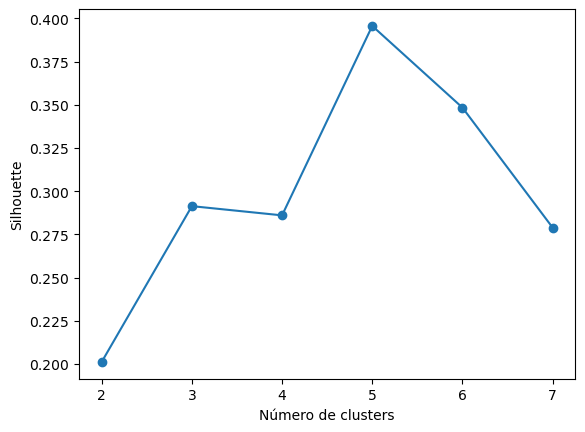

In [25]:
# Criterios de selección de k: Elbow y Silhouette.

inertia = []
silhouette = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto',random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia (Elbow)")
plt.show()

plt.plot(K_range, silhouette, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

**Resultado:** al igual que en 2023, el codo se observa alrededor de *k = 5* y el promedio de
silhouette es máximo en *k = 5*. Por lo tanto, **adoptamos k = 5** para el modelo principal. También se probaron clusterizaciones con 4 y 6 clusters pero *el mejor resultado fue con k=5*.  

In [26]:
#Clusterización en 5d
pca = PCA(n_components=2, random_state=42)
#Z = pca.fit_transform(X_scaled) 
#comentado por si se prefiere clusterizar en 2d
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df_2010["Cluster"] = labels
print(df_2010[["Cluster"]])

                 Cluster
Country                 
Austria                3
Belgium                2
Czechia                0
Denmark                4
Estonia                0
Finland                3
France                 2
Germany                0
Greece                 0
Hungary                2
Ireland                1
Italy                  1
Latvia                 3
Lithuania              1
Luxembourg             1
Poland                 0
Portugal               4
Slovak Republic        2
Spain                  4
Sweden                 3
The Netherlands        1


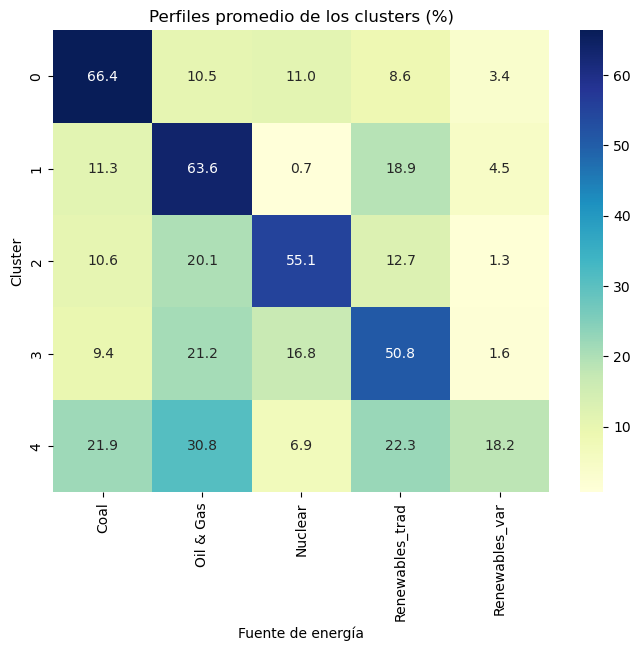

In [27]:
Z = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    "PC1": Z[:,0],
    "PC2": Z[:,1],
    "Cluster": df_2010["Cluster"].values,
    "Country": df_2010.index
})

profiles = (
    df_2010.drop(columns=["Cluster", "Cluster_hier"], errors="ignore")
          .assign(Cluster=df_2010["Cluster"])
          .groupby("Cluster").mean()
          .sort_index()
)

# Heatmap de perfiles promedio por cluster
plt.figure(figsize=(8,6))
sns.heatmap(profiles, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfiles promedio de los clusters (%)")
plt.ylabel("Cluster")
plt.xlabel("Fuente de energía")
plt.show()

C:\Users\Santiago\AppData\Local\Temp\ipykernel_27388\4069059330.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10")


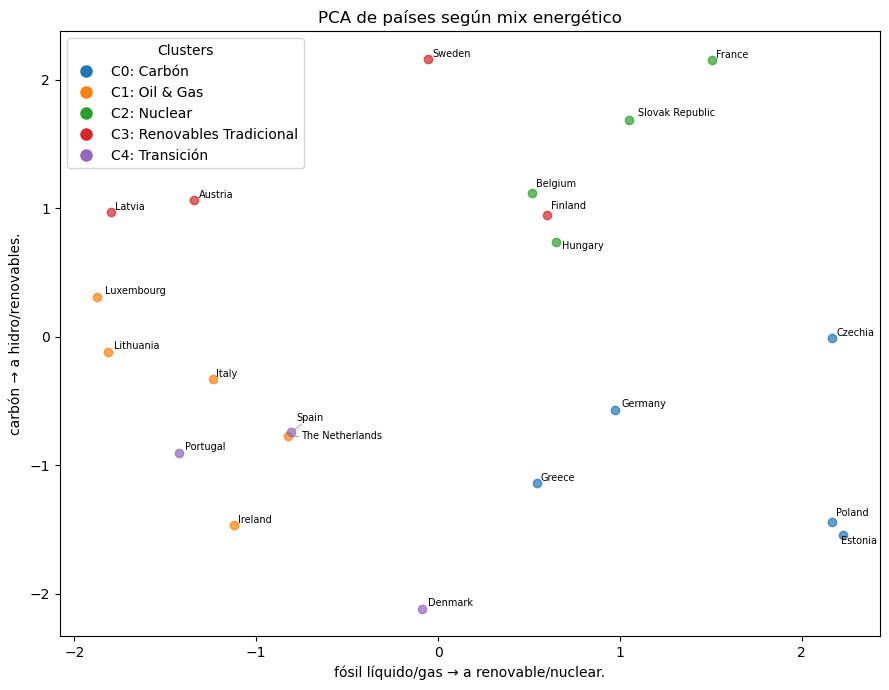

In [28]:
from matplotlib.lines import Line2D
clusters_sorted = np.sort(np.unique(labels))

cluster_labels = {
    0: "C0: Carbón",
    1: "C1: Oil & Gas",
    2: "C2: Nuclear",
    3: "C3: Renovables Tradicional",
    4: "C4: Transición",
}
cmap = plt.cm.get_cmap("tab10")
palette = {c: cmap(i % 10) for i, c in enumerate(sorted(clusters_sorted))}

plt.figure(figsize=(9,7))
# scatter de países
for c in clusters_sorted:
    mask = (labels == c)
    plt.scatter(Z[mask,0], Z[mask,1], alpha=0.7)

# etiquetas de países sin superposición
texts = []
for (x, y), name in zip(Z, df_2010.index):
    texts.append(plt.text(x, y, name, fontsize=7))

# autoajuste
adjust_text(texts,
            only_move={'points':'y', 'texts':'y'},  # mueve en vertical para ordenarlos
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

legend_elements = []

# proxy por cada cluster
for c in clusters_sorted:
    legend_elements.append(
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=palette[c], markeredgecolor=palette[c],
               markersize=8, label=cluster_labels.get(c, f"C{c}"))
    )

plt.xlabel("fósil líquido/gas → a renovable/nuclear.")
plt.ylabel("carbón → a hidro/renovables.")
plt.title("PCA de países según mix energético")
plt.legend(handles=legend_elements,title="Clusters",loc="upper left")
plt.tight_layout()
plt.show()

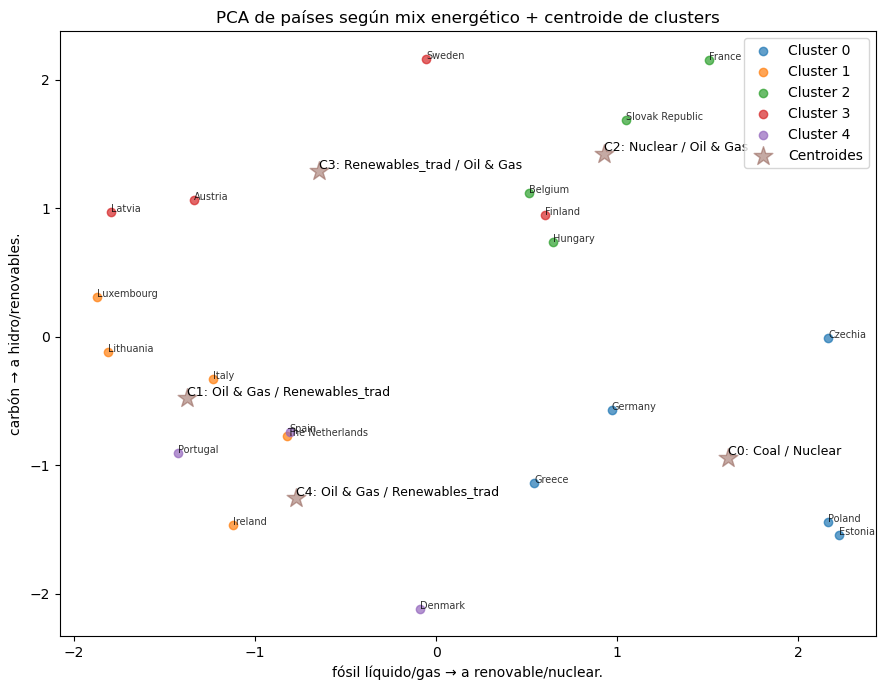

In [29]:
# 1) Matriz de features (sin la col Cluster)
features_df = df_2010.drop(columns=["Cluster"], errors="ignore").copy()
feature_names = features_df.columns.tolist()

# 3) PCA 2D
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

# 4) Centroides en espacio original-escalado y su proyección al PCA     
labels = df_2010["Cluster"].values

centroids = []
for c in clusters_sorted:
    mask = (labels == c)
    centroids.append(X_scaled[mask].mean(axis=0))
centroids = np.vstack(centroids)
centroids_pca = pca.transform(centroids)

# 5) Perfiles promedio por cluster (en % para nombrar centroides)
profiles = (df_2010.drop(columns="Cluster")
                  .assign(Cluster=labels)
                  .groupby("Cluster").mean()
                  .sort_index())

# Nombres humanos por top-2 fuentes
topk = 2
centroid_names = []
for c in profiles.index:
    tops = profiles.loc[c].sort_values(ascending=False).head(topk).index.tolist()
    centroid_names.append(" / ".join(tops))

# 6) Scatter: países por cluster + centroides
plt.figure(figsize=(9,7))
for c in clusters_sorted:
    mask = (labels == c)
    plt.scatter(Z[mask,0], Z[mask,1], label=f"Cluster {c}", alpha=0.7)

# centroides (marcador grande tipo X)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker="*", s=200, label="Centroides", alpha=0.5)

# Etiquetas de centroides con top-2 fuentes
for i, c in enumerate(clusters_sorted):
    plt.text(centroids_pca[i,0], centroids_pca[i,1],
             f"C{c}: {centroid_names[i]}",
             fontsize=9, ha="left", va="bottom")

# (Opcional) anotar países — activá si querés ver nombres
annotate_countries = True
if annotate_countries:
    for (x, y), name in zip(Z, df_2010.index):
        plt.text(x, y, name, fontsize=7, alpha=0.8)

plt.xlabel("fósil líquido/gas → a renovable/nuclear.")
plt.ylabel("carbón → a hidro/renovables.")
plt.title("PCA de países según mix energético + centroide de clusters")
plt.legend()
plt.tight_layout()
plt.show()


## Caracterización de los clusters

A partir de los perfiles promedio de cada grupo, se pueden resumir las principales características energéticas de los clusters identificados:

- **Cluster 0 → Carbón**  
  Sistemas eléctricos con una marcada dependencia del **carbón** (≈66%), acompañado por una participación secundaria de energía nuclear y Oil & Gas. Representa países cuya generación eléctrica aún se apoya principalmente en combustibles sólidos.

- **Cluster 1 → Oil & Gas**  
  Predominio de **gas y petróleo** (≈64%), complementados por renovables tradicionales (≈19%). Corresponde a matrices fuertemente dependientes de combustibles fósiles líquidos y gaseosos.

- **Cluster 2 → Nuclear**  
  Perfil dominado por la **energía nuclear** (≈55%), acompañado por una participación moderada de Oil & Gas (≈20%). Agrupa países con una base eléctrica nuclear consolidada.

- **Cluster 3 → Renovables tradicionales**  
  Matrices donde predominan las **renovables tradicionales** (≈51%), principalmente hidroeléctrica, complementadas por Oil & Gas (≈21%) y energía nuclear (≈17%). Representa sistemas con una elevada participación de fuentes renovables gestionables.

- **Cluster 4 → Mixto**  
  Perfil altamente diversificado, sin una fuente claramente dominante. Combina **Oil & Gas** (≈31%), **carbón** (≈22%), **renovables tradicionales** (≈22%) y **renovables variables** (≈18%). Representa matrices de transición o con una elevada diversificación tecnológica.

- **Algunos casos atípicos:** Son países cuya pertenencia a un cluster simplifica características particulares de su matriz eléctrica.
  - **Alemania:** Se integra en un perfil carbonífero debido al importante peso del carbón en 2010, aunque ya presentaba una participación creciente de energías renovables.
  - **Suecia:** Se agrupa con países de perfil renovable tradicional por el peso de la energía hidroeléctrica. Sin embargo, esta clasificación oculta la elevada participación de la energía nuclear, que la aproxima a países como Francia o Finlandia.

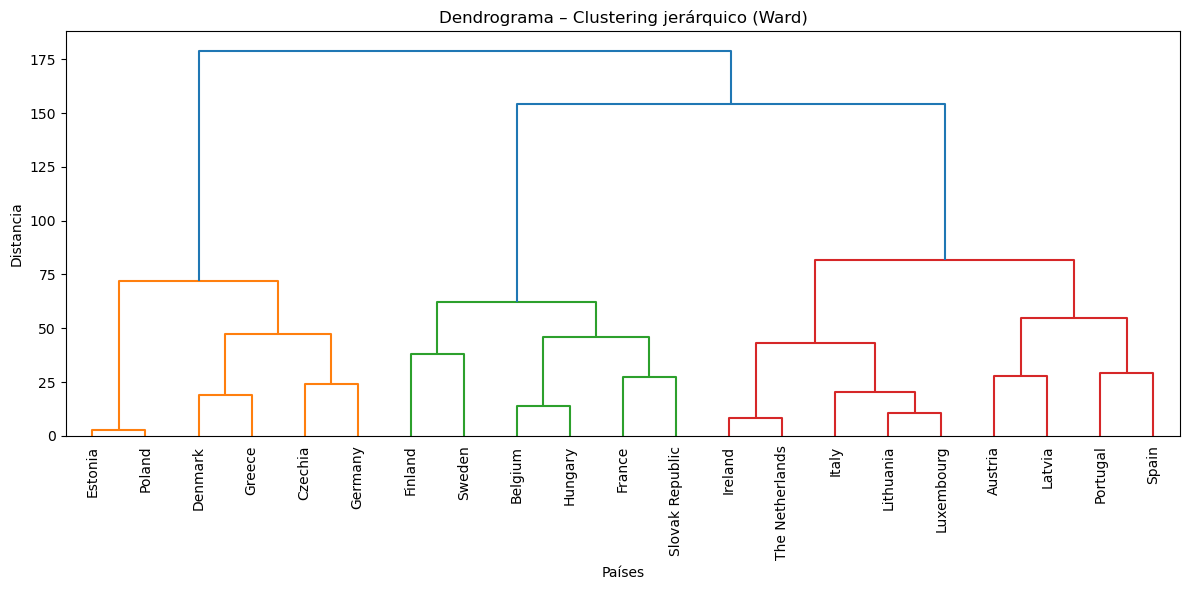

                 Cluster_hier
Country                      
Austria                     5
Belgium                     3
Czechia                     2
Denmark                     2
Estonia                     1
Finland                     3
France                      3
Germany                     2
Greece                      2
Hungary                     3
Ireland                     4
Italy                       4
Latvia                      5
Lithuania                   4
Luxembourg                  4
Poland                      1
Portugal                    5
Slovak Republic             3
Spain                       5
Sweden                      3
The Netherlands             4


In [30]:
X = df_2010.drop(columns=["Cluster"], errors="ignore").values

# --- 2. Clustering jerárquico (Ward) ---
Z_link = linkage(X, method='ward')

# --- 3. Graficar dendrograma ---
plt.figure(figsize=(12, 6))
dendrogram(
    Z_link,
    labels=df_2010.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None # o un valor para colorear cortes
)
plt.title("Dendrograma – Clustering jerárquico (Ward)")
plt.xlabel("Países")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

# --- 4. Si querés extraer clusters (ej: 6) ---
clusters_hier = fcluster(Z_link, 5,  criterion='maxclust')
df_2010["Cluster_hier"] = clusters_hier

print(df_2010[["Cluster_hier"]])


## Comparación entre K-means y Clustering jerárquico (5 clusters)

Ambos métodos permiten identificar cinco agrupamientos con perfiles energéticos similares, aunque presentan diferencias en algunos países con matrices más híbridas o diversificadas.

- **Coincidencias generales**
  - Los principales bloques (**Carbón, Nuclear, Oil & Gas y Renovables tradicionales**) aparecen de forma consistente en ambos métodos.
  - Países con perfiles muy definidos, como **Polonia, Estonia, Francia, Finlandia e Irlanda**, mantienen prácticamente la misma caracterización energética.

- **Diferencias destacadas**
  - **Alemania:**
    - *K-means:* integra el cluster de Carbón.
    - *Jerárquico:* se agrupa con Chequia, Grecia y Dinamarca dentro de un bloque carbonífero más amplio.
    - → Ambos métodos reconocen el importante peso del carbón, aunque difieren en los países con los que comparte mayor similitud.

  - **Chequia:**
    - *K-means:* forma parte del cluster Nuclear.
    - *Jerárquico:* se incorpora al bloque de Carbón.
    - → Refleja el carácter híbrido de su matriz eléctrica en 2010, con una elevada participación tanto de carbón como de energía nuclear.

  - **Suecia:**
    - *K-means:* se integra al cluster de Renovables tradicionales.
    - *Jerárquico:* queda agrupada junto a Finlandia dentro del bloque nuclear.
    - → La clasificación depende de si el algoritmo prioriza el elevado peso de la hidroelectricidad o la combinación hidro–nuclear característica del país.

  - **Austria:**
    - *K-means:* integra el cluster de Renovables tradicionales.
    - *Jerárquico:* se agrupa con España, Portugal y Letonia.
    - → Ambos métodos resaltan el predominio de fuentes renovables, aunque difieren en el perfil de países con los que comparte mayor similitud.

- **Interpretación**
  - **K-means:** genera clusters más homogéneos y fácilmente interpretables, facilitando la identificación de perfiles promedio de generación eléctrica.
  - **Clustering jerárquico:** permite observar con mayor detalle las relaciones de similitud entre países y resalta aquellos casos con matrices híbridas que pueden pertenecer razonablemente a más de una tipología.

**Conclusión:**

Los resultados obtenidos mediante K-means y clustering jerárquico muestran una elevada consistencia en la identificación de las principales tipologías de matrices eléctricas europeas en 2010. Las diferencias se concentran en países con estructuras energéticas más diversificadas, mientras que los perfiles más definidos permanecen estables en ambos métodos. En conjunto, ambos enfoques resultan complementarios: K-means facilita la construcción de tipologías representativas y el análisis jerárquico aporta evidencia adicional sobre la robustez de la clasificación y las relaciones de similitud entre países.

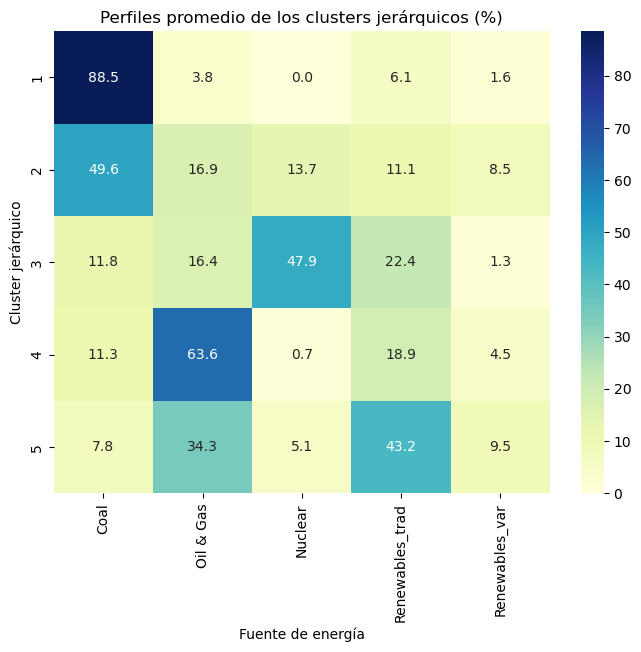

In [31]:
profiles_hier = (
    df_2010.drop(columns=["Cluster"], errors="ignore") 
          .assign(Cluster_hier=df_2010["Cluster_hier"])
          .groupby("Cluster_hier").mean()
          .sort_index()
)
plt.figure(figsize=(8,6))
sns.heatmap(profiles_hier, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfiles promedio de los clusters jerárquicos (%)")
plt.ylabel("Cluster jerárquico")
plt.xlabel("Fuente de energía")
plt.show()

## Comparación de perfiles promedio: K-Means vs. Clustering jerárquico (2010)

- **Clusters de Carbón**
  - *K-Means (C0):* 66% carbón.
  - *Jerárquico (C1):* 89% carbón.
  → Ambos métodos identifican un bloque claramente carbonífero. El clustering jerárquico concentra los casos más extremos, mientras que K-Means incorpora matrices con una mayor diversificación.

- **Clusters Oil & Gas**
  - *K-Means (C1):* 64% Oil & Gas.
  - *Jerárquico (C4):* 64% Oil & Gas.
  → Existe una correspondencia prácticamente exacta entre ambos métodos, confirmando un grupo con predominio de generación basada en gas y petróleo.

- **Clusters Nucleares**
  - *K-Means (C2):* 55% nuclear.
  - *Jerárquico (C3):* 48% nuclear.
  → Ambos algoritmos identifican un perfil caracterizado por una elevada participación de energía nuclear, complementada por renovables tradicionales.

- **Clusters de Renovables tradicionales**
  - *K-Means (C3):* 51% renovables tradicionales.
  - *Jerárquico (C5):* 43% renovables tradicionales.
  → Los dos métodos reconocen un grupo donde predominan las renovables tradicionales (principalmente hidráulica), aunque el clustering jerárquico incorpora una mayor participación de Oil & Gas.

- **Clusters Mixtos**
  - *K-Means (C4):* 31% Oil & Gas, 22% carbón, 22% renovables tradicionales y 18% renovables variables.
  - *Jerárquico (C2):* 50% carbón, acompañado por participaciones moderadas de Oil & Gas, nuclear y renovables.
  → Este es el principal punto de divergencia entre ambos métodos. Mientras K-Means identifica un perfil claramente diversificado, el clustering jerárquico incorpora parte de esos países a un perfil con mayor predominio del carbón, reduciendo la heterogeneidad del grupo.

**Conclusión:**

Los dos algoritmos convergen en la identificación de las principales tipologías presentes en las matrices eléctricas europeas de 2010: perfiles carboníferos, nucleares, dominados por Oil & Gas y renovables tradicionales. Las diferencias aparecen principalmente en los clusters de transición o de composición más heterogénea, mientras que los perfiles dominados por carbón, Oil & Gas, energía nuclear y renovables tradicionales permanecen notablemente estables entre ambos métodos. En conjunto, la elevada correspondencia entre ambos enfoques aporta evidencia adicional sobre la robustez de la clasificación obtenida y respalda la utilización de K-Means como método principal para la caracterización de las tipologías energéticas.

In [32]:
df_2010 = eu.merge(
    df_2010,
    left_on="NAME_ENGL",
    right_on="Country",
    how="left"
)

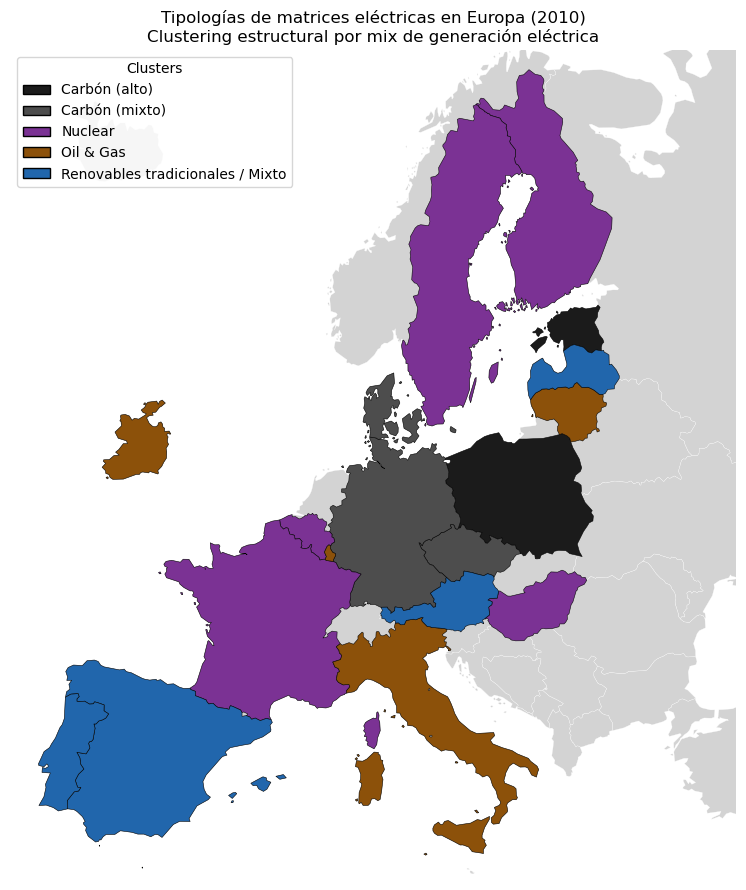

In [33]:
from matplotlib.patches import Patch

# Paleta semántica
cluster_labels = {
    1: "Carbón (alto)",
    2: "Carbón (mixto)",
    3: "Nuclear",
    4: "Oil & Gas",
    5: "Renovables tradicionales / Mixto",
}

cluster_colors = {
    1: "#1b1b1b",  # Carbón alto → negro intenso
    2: "#4d4d4d",  # Carbón mixto → gris oscuro
    3: "#7b3294",  # Nuclear → violeta
    4: "#8c510a",  # Oil & Gas → marrón
    5: "#2166ac",  # Renovables tradicionales → azul
}


fig, ax = plt.subplots(figsize=(9, 9))

# 1) Fondo: países sin cluster (gris)
df_2010[df_2010["Cluster_hier"].isna()].plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.2
)

# Máscara por zona (Europa)
xmin, xmax = 2500000, 6000000
ymin, ymax = 1400000, 5400000

# 2) Países con cluster: plot uno por uno para controlar color
for c, color in cluster_colors.items():
    df_2010[df_2010["Cluster_hier"] == c].plot(
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.4
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Leyenda manual
legend_elements = [
    Patch(facecolor=cluster_colors[c], edgecolor="black", label=cluster_labels[c])
    for c in cluster_colors
]

ax.legend(
    handles=legend_elements,
    title="Clusters",
    loc="upper left",
    frameon=True
)

ax.set_title(
    "Tipologías de matrices eléctricas en Europa (2010)\n"
    "Clustering estructural por mix de generación eléctrica",
    fontsize=12
)

ax.axis("off")
plt.tight_layout()
plt.show()



# Análisis comparativo: evolución de las matrices eléctricas europeas (2010-2023)

La aplicación de una misma metodología de clustering sobre las matrices eléctricas de 2010 y 2023 permitió identificar la evolución de los principales perfiles de generación eléctrica en la Unión Europea.

En ambos años, tanto K-Means como el clustering jerárquico convergen en la identificación de grandes tipologías energéticas, lo que aporta robustez metodológica a los resultados y permite realizar comparaciones temporales consistentes.

La principal diferencia entre ambos años radica en el grado de especialización de las matrices eléctricas. Mientras que en 2010 predominaban perfiles más híbridos y diversificados, en 2023 los clusters presentan una identidad tecnológica mucho más definida, reflejando el avance de la transición energética europea.

Entre los principales cambios observados destacan:

- Consolidación de un **cluster de Renovables Variables**, asociado al crecimiento de la generación eólica y solar durante la última década.
- Menor presencia de perfiles dominados por el carbón y mayor diferenciación entre las distintas tipologías de generación.
- Mayor especialización entre países con predominio de energía nuclear y aquellos orientados hacia fuentes renovables.
- Persistencia de un grupo reducido de países con elevada dependencia de **Oil & Gas**, concentrados principalmente en el sur y oeste de Europa.

La comparación entre 2010 y 2023 sugiere que la transición energética europea no implicó una convergencia hacia un único modelo de generación, sino una creciente especialización de las matrices nacionales. Mientras algunos países consolidaron perfiles basados en la energía nuclear, otros profundizaron el desarrollo de renovables tradicionales o renovables variables, configurando tipologías tecnológicas cada vez más diferenciadas.

Asimismo, la comparación entre K-Means y clustering jerárquico muestra que los perfiles más extremos (carbón, nuclear, renovables tradicionales y Oil & Gas) permanecen estables entre ambos métodos, mientras que las diferencias aparecen principalmente en países con matrices híbridas o en transición. Esto respalda la utilización de K-Means como herramienta principal para caracterizar tipologías energéticas, utilizando el clustering jerárquico como validación adicional de la estructura encontrada.

---

# Síntesis ejecutiva

El análisis comparativo de las matrices eléctricas de 21 países de la Unión Europea para los años **2010 y 2023** permitió identificar la evolución de las principales tipologías de generación eléctrica mediante técnicas de clustering (K-Means y clustering jerárquico).

En ambos períodos los algoritmos identifican perfiles energéticos similares, lo que demuestra que la estructura de las matrices eléctricas europeas puede describirse mediante un conjunto reducido de tipologías claramente diferenciadas. Sin embargo, la comparación temporal evidencia una transformación significativa en la composición de dichos perfiles.

## Hallazgos principales

- **Robustez metodológica:** K-Means y clustering jerárquico convergen en la identificación de los principales perfiles energéticos, validando la estabilidad de los resultados.

- **Mayor especialización de las matrices eléctricas:** En 2010 predominaban perfiles más mixtos y heterogéneos. En 2023 los clusters presentan una identidad tecnológica más definida, reflejando el avance de la transición energética europea.

- **Consolidación de las renovables variables:** La expansión de la generación eólica y solar da lugar a un perfil específico que en 2010 aún no aparecía claramente diferenciado.

- **Persistencia de perfiles estructurales:** Los países con fuerte tradición nuclear o elevada dependencia del carbón mantienen características relativamente estables durante el período analizado, aunque con cambios en la intensidad de cada fuente.

- **Casos híbridos y atípicos:**
  - **Alemania** mantiene un perfil complejo debido a la coexistencia de carbón y renovables.
  - **Suecia** combina una elevada participación de energía hidroeléctrica y nuclear, situándose en el límite entre ambos perfiles.
  - **Chequia** presenta características tanto del bloque carbonífero como del nuclear, dependiendo del método de agrupamiento utilizado.

- **Comparación metodológica:**
  - **K-Means** genera perfiles promedio compactos y fácilmente interpretables.
  - **Clustering jerárquico** permite identificar afinidades más finas entre países y resalta con mayor claridad los casos de transición.

- **Diversificación tecnológica:** La evolución observada entre 2010 y 2023 muestra que la transición energética europea no implicó una homogeneización de las matrices eléctricas, sino una creciente especialización nacional basada en distintas combinaciones de energía nuclear, renovables y combustibles fósiles.

- **Dependencia fósil limitada:** Sólo un grupo reducido de países mantiene una elevada dependencia de **Oil & Gas**, lo que sugiere una exposición desigual frente a shocks internacionales sobre el mercado del gas.

- **Riesgos focalizados:** Países como **Grecia, Italia, Irlanda y Países Bajos** continúan presentando una mayor vulnerabilidad frente a la volatilidad del gas natural debido al peso de esta fuente en su generación eléctrica.

## Limitaciones del análisis

Los resultados obtenidos deben interpretarse considerando algunas limitaciones metodológicas. El análisis se basa exclusivamente en la composición porcentual de la generación eléctrica de cada país, por lo que los clusters representan similitudes estructurales entre matrices eléctricas y no una evaluación integral de los sistemas energéticos.

En consecuencia, no se incorporan variables relevantes como la capacidad instalada, la demanda eléctrica, las emisiones de CO₂, los costos de generación, las interconexiones internacionales, el grado de dependencia de las importaciones energéticas o el funcionamiento del mercado eléctrico. Estas dimensiones pueden influir en el desempeño y la seguridad energética de cada país, pero exceden el alcance del presente trabajo.

Por ello, los resultados deben interpretarse como una herramienta de clasificación y análisis exploratorio de las tipologías de generación eléctrica, útil para identificar patrones comunes y analizar su evolución entre 2010 y 2023, más que como una evaluación exhaustiva de la política energética de cada Estado miembro.

## Impacto de la crisis del gas en la UE-27

Si bien el análisis de clusters muestra que la dependencia directa del gas y petróleo se concentra en un número reducido de países, la crisis energética de 2022 produjo aumentos generalizados del precio de la electricidad en toda la Unión Europea.

Tal como se desarrolla en el informe **[*Impacto de la guerra de Ucrania en la matriz energética de la UE-27*](https://drive.google.com/file/d/1X0Ttpvtd43FUVFGUnAoom7ZYPBBvVRPw/view?usp=sharing)**, este fenómeno se explica por el mecanismo marginalista de formación de precios del mercado eléctrico europeo. Al ser el gas natural la tecnología marginal en numerosos períodos, las variaciones de su precio se trasladaron al mercado mayorista incluso en países con matrices eléctricas altamente diversificadas.

En consecuencia, los resultados del presente trabajo permiten distinguir dos dimensiones complementarias: por un lado, la **vulnerabilidad estructural**, asociada a la composición de cada matriz eléctrica y a su grado de dependencia de los combustibles fósiles; por otro, la **vulnerabilidad de mercado**, derivada del diseño del sistema eléctrico europeo, que transmite las variaciones del precio del gas al conjunto de los Estados miembros.